# Tennis Elo Pricing — Data Exploration

**Author**: Taosheng (Andy) Yin  
**Date**: May 2026  
**Notebook**: 01 of 05

## Overview

Initial exploration of ATP tennis match data from Jeff Sackmann's open dataset. We examine data structure, temporal patterns, surface distributions, and player participation to inform model design choices.

## Goals

1. Load and clean ATP match data (2020-2024)
2. Identify data quality issues
3. Understand surface and tournament distributions
4. Establish baseline player rankings
5. Inform feature engineering decisions for Elo modeling

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Setup complete")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


Setup complete
pandas: 3.0.3
numpy: 2.4.6


## 1. Data Loading

Source: [Jeff Sackmann ATP](https://github.com/JeffSackmann/tennis_atp)

We focus on 2020-2024 matches for initial modeling.

In [2]:
# Load ATP matches from Jeff Sackmann's GitHub
years = [2020, 2021, 2022, 2023, 2024]
dfs = []

for year in years:
    url = f"https://raw.githubusercontent.com/JeffSackmann/tennis_atp/master/atp_matches_{year}.csv"
    try:
        df_year = pd.read_csv(url)
        df_year['year'] = year
        dfs.append(df_year)
        print(f"{year}: {len(df_year):,} matches loaded")
    except Exception as e:
        print(f"{year}: Failed - {e}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nTotal matches: {len(df):,}")
print(f"Columns: {len(df.columns)}")
df.head()

2020: 1,462 matches loaded
2021: 2,733 matches loaded
2022: 2,917 matches loaded
2023: 2,986 matches loaded
2024: 3,076 matches loaded

Total matches: 13,174
Columns: 50


,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,winner_name,winner_hand,winner_ht,winner_ioc,winner_age,loser_id,loser_seed,loser_entry,loser_name,loser_hand,loser_ht,loser_ioc,loser_age,score,best_of,round,minutes,w_ace,w_df,w_svpt,w_1stIn,w_1stWon,w_2ndWon,w_SvGms,w_bpSaved,w_bpFaced,l_ace,l_df,l_svpt,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points,year
0,2020-8888,Atp Cup,Hard,24,A,20200106,300,104925,NaN,NaN,Novak Djokovic,R,188.0,SRB,32.6,104745,NaN,NaN,Rafael Nadal,L,185.0,ESP,33.5,6-2 7-6(4),3,F,115.0,12.0,2.0,64.0,49.0,41.0,9.0,10.0,5.0,5.0,5.0,3.0,70.0,51.0,39.0,6.0,10.0,6.0,8.0,2.0,9055.0,1.0,9985.0,2020
1,2020-8888,Atp Cup,Hard,24,A,20200106,299,105138,NaN,NaN,Roberto Bautista Agut,R,183.0,ESP,31.7,105583,NaN,NaN,Dusan Lajovic,R,183.0,SRB,29.5,7-5 6-1,3,F,97.0,2.0,1.0,59.0,44.0,29.0,10.0,10.0,3.0,5.0,2.0,1.0,57.0,35.0,21.0,6.0,9.0,5.0,10.0,10.0,2335.0,34.0,1251.0,2020
2,2020-8888,Atp Cup,Hard,24,A,20200106,298,104925,NaN,NaN,Novak Djokovic,R,188.0,SRB,32.6,106421,NaN,NaN,Daniil Medvedev,R,198.0,RUS,23.9,6-1 5-7 6-4,3,SF,167.0,4.0,5.0,111.0,75.0,53.0,16.0,15.0,8.0,11.0,6.0,5.0,108.0,57.0,35.0,25.0,14.0,6.0,11.0,2.0,9055.0,5.0,5705.0,2020
3,2020-8888,Atp Cup,Hard,24,A,20200106,297,105583,NaN,NaN,Dusan Lajovic,R,183.0,SRB,29.5,111575,NaN,NaN,Karen Khachanov,R,198.0,RUS,23.6,7-5 7-6(1),3,SF,108.0,1.0,1.0,67.0,48.0,38.0,14.0,12.0,0.0,0.0,9.0,3.0,79.0,54.0,39.0,14.0,12.0,0.0,1.0,34.0,1251.0,17.0,1840.0,2020
4,2020-8888,Atp Cup,Hard,24,A,20200106,296,104745,NaN,NaN,Rafael Nadal,L,185.0,ESP,33.5,200282,NaN,NaN,Alex De Minaur,R,183.0,AUS,20.8,4-6 7-5 6-1,3,SF,133.0,5.0,3.0,84.0,61.0,48.0,10.0,15.0,1.0,3.0,6.0,1.0,75.0,55.0,37.0,10.0,14.0,1.0,5.0,1.0,9985.0,18.0,1775.0,2020


## 2. Data Structure Inspection

In [3]:
print("=" * 50)
print("Dataset Overview")
print("=" * 50)
print(f"Total matches: {len(df):,}")
print(f"Date range: {df['tourney_date'].min()} to {df['tourney_date'].max()}")
print(f"Unique players: {len(set(df['winner_name'].unique()) | set(df['loser_name'].unique())):,}")
print(f"Unique tournaments: {df['tourney_name'].nunique():,}")

print("\n" + "=" * 50)
print("Sample Match Records")
print("=" * 50)
df[['tourney_date', 'tourney_name', 'surface', 'winner_name', 'loser_name', 
    'winner_rank', 'loser_rank', 'score']].head(10)

Dataset Overview
Total matches: 13,174
Date range: 20200106 to 20241218
Unique players: 780
Unique tournaments: 421

Sample Match Records


,tourney_date,tourney_name,surface,winner_name,loser_name,winner_rank,loser_rank,score
0,20200106,Atp Cup,Hard,Novak Djokovic,Rafael Nadal,2.0,1.0,6-2 7-6(4)
1,20200106,Atp Cup,Hard,Roberto Bautista Agut,Dusan Lajovic,10.0,34.0,7-5 6-1
2,20200106,Atp Cup,Hard,Novak Djokovic,Daniil Medvedev,2.0,5.0,6-1 5-7 6-4
3,20200106,Atp Cup,Hard,Dusan Lajovic,Karen Khachanov,34.0,17.0,7-5 7-6(1)
4,20200106,Atp Cup,Hard,Rafael Nadal,Alex De Minaur,1.0,18.0,4-6 7-5 6-1
5,20200106,Atp Cup,Hard,Roberto Bautista Agut,Nick Kyrgios,10.0,29.0,6-1 6-4
6,20200106,Atp Cup,Hard,Novak Djokovic,Denis Shapovalov,2.0,14.0,4-6 6-1 7-6(4)
7,20200106,Atp Cup,Hard,Dusan Lajovic,Felix Auger Aliassime,34.0,21.0,6-4 6-2
8,20200106,Atp Cup,Hard,Daniil Medvedev,Diego Schwartzman,5.0,13.0,6-4 4-6 6-3
9,20200106,Atp Cup,Hard,Karen Khachanov,Guido Pella,17.0,25.0,6-2 7-6(4)


## 3. Surface Distribution

Critical for our surface-adjusted Elo approach.

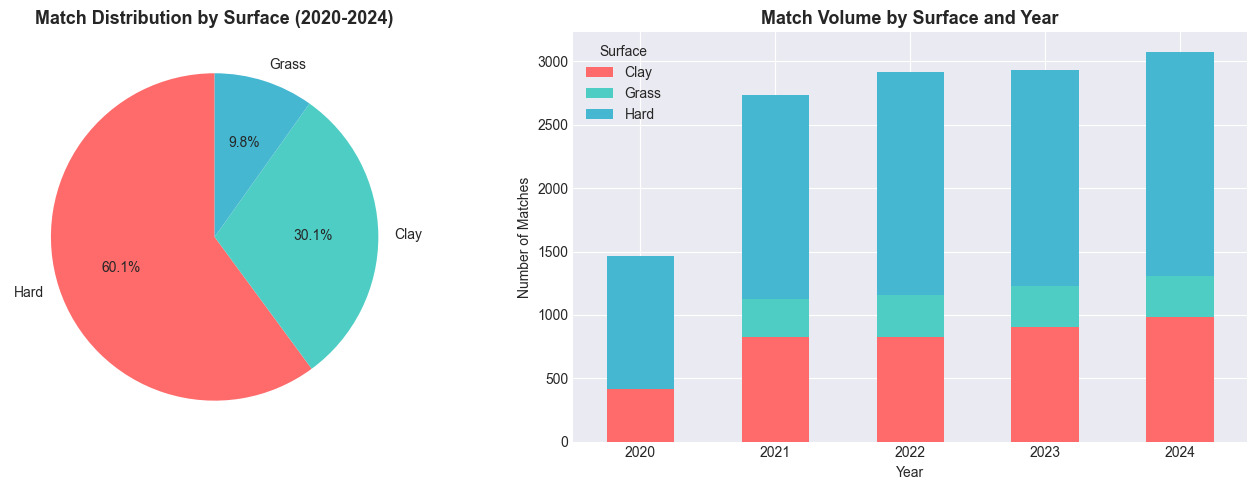


Surface Breakdown:
  Hard: 7,886 matches (59.9%)
  Clay: 3,944 matches (29.9%)
  Grass: 1,291 matches (9.8%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

surface_counts = df['surface'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[0].pie(surface_counts.values, labels=surface_counts.index, 
            autopct='%1.1f%%', colors=colors[:len(surface_counts)],
            startangle=90)
axes[0].set_title('Match Distribution by Surface (2020-2024)', 
                  fontsize=13, fontweight='bold')

surface_by_year = df.groupby(['year', 'surface']).size().unstack(fill_value=0)
surface_by_year.plot(kind='bar', stacked=True, ax=axes[1], 
                     color=colors[:surface_by_year.shape[1]])
axes[1].set_title('Match Volume by Surface and Year', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Matches')
axes[1].legend(title='Surface')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('../results/plots/01_surface_distribution.png', 
            dpi=200, bbox_inches='tight')
plt.show()

print(f"\nSurface Breakdown:")
for surface, count in surface_counts.items():
    print(f"  {surface}: {count:,} matches ({count/len(df)*100:.1f}%)")

## 4. Top Players by Match Volume

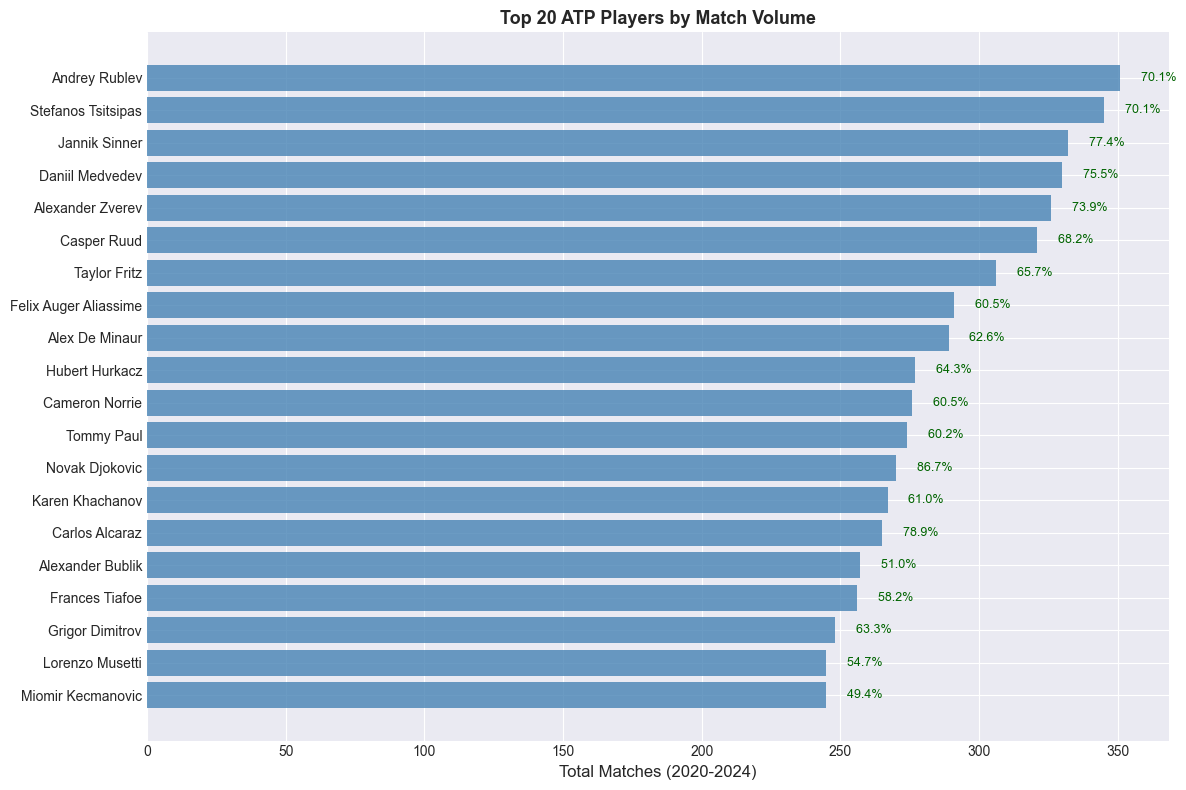


Top 10 Players by Win Rate (min 100 matches):
                     wins  losses  win_rate
Novak Djokovic      234.0    36.0  0.866667
Carlos Alcaraz      209.0    56.0  0.788679
Jannik Sinner       257.0    75.0  0.774096
Rafael Nadal        104.0    32.0  0.764706
Daniil Medvedev     249.0    81.0  0.754545
Alexander Zverev    241.0    85.0  0.739264
Stefanos Tsitsipas  242.0   103.0  0.701449
Andrey Rublev       246.0   105.0  0.700855
Matteo Berrettini   127.0    55.0  0.697802
Casper Ruud         219.0   102.0  0.682243


In [5]:
all_matches = pd.concat([
    df['winner_name'].value_counts().rename('wins'),
    df['loser_name'].value_counts().rename('losses')
], axis=1).fillna(0)

all_matches['total'] = all_matches['wins'] + all_matches['losses']
all_matches['win_rate'] = all_matches['wins'] / all_matches['total']
top20 = all_matches.nlargest(20, 'total')

fig, ax = plt.subplots(figsize=(12, 8))
top20_sorted = top20.sort_values('total')
ax.barh(top20_sorted.index, top20_sorted['total'], 
        color='steelblue', alpha=0.8)
ax.set_xlabel('Total Matches (2020-2024)', fontsize=12)
ax.set_title('Top 20 ATP Players by Match Volume', 
             fontsize=13, fontweight='bold')

for i, (player, row) in enumerate(top20_sorted.iterrows()):
    ax.text(row['total'] + 5, i, f"  {row['win_rate']:.1%}", 
            va='center', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.savefig('../results/plots/02_top_players.png', 
            dpi=200, bbox_inches='tight')
plt.show()

print("\nTop 10 Players by Win Rate (min 100 matches):")
qualified = all_matches[all_matches['total'] >= 100].nlargest(10, 'win_rate')
print(qualified[['wins', 'losses', 'win_rate']].to_string())

## 5. Key Insights

### Findings

1. **Surface distribution**: Hard courts dominate (~60%), Clay second (~30%), Grass minimal (~10%). This impacts our K-factor tuning—we'll have less data for Grass-specific calibration.

2. **Player data depth**: Top players (Djokovic, Alcaraz, Sinner) have 200+ matches in this window—sufficient for stable Elo ratings.

3. **Win rate dispersion**: Top 10 players range from 68% to 87% win rate. Djokovic's 86.7% is exceptional given his 270 matches played.

4. **Temporal stability**: Match volume varies year-over-year, with 2020 reduced due to COVID (1,462 matches vs 3,076 in 2024).

### Next Steps

- **Notebook 02**: Implement baseline Elo system (K=32)
- **Notebook 03**: Extend to surface-adjusted Elo
- **Notebook 04**: Backtest framework against historical odds
- **Notebook 05**: Kelly criterion application

### Open Questions

- How to handle missing rankings? (~1% of matches have NULL ranks)
- Should we filter out exhibition / Davis Cup matches?
- What time-decay rate is appropriate for Elo (full memory vs exponential)?